# Tâche 3 — MLP avec Gestion de l'Incertitude

Ce notebook implémente uniquement la Tâche 3 :
- Entraîner un MLP à sortie probabiliste
- Estimer l'incertitude via Monte Carlo Dropout
- Analyser les cas incertains (`max_prob < 0.7`)

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loader import load_dataset_split
from src.data.preprocess import preprocess_dataset
from src.models.log_reg import flatten_images
from src.models.mlp import build_mlp_classifier, train_mlp_classifier, predict_probabilities
from src.models.uncertainty import mc_dropout_predict, summarize_uncertainty

2026-03-02 16:15:05.946675: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-02 16:15:05.947166: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 16:15:06.018466: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 16:15:07.608941: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
# Paramètres (mode notebook rapide recommandé)
DATA_DIR = PROJECT_ROOT / 'data'
TRAIN_DIR = DATA_DIR / 'Training'
TEST_DIR = DATA_DIR / 'Testing'

IMG_SIZE = (32, 32)
EPOCHS = 5
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
DROPOUT_RATE = 0.3
HIDDEN_UNITS = (128, 64)
N_ITER_MC = 10
UNCERTAINTY_THRESHOLD = 0.7

assert TRAIN_DIR.exists(), f'Dossier introuvable: {TRAIN_DIR}'
assert TEST_DIR.exists(), f'Dossier introuvable: {TEST_DIR}'

print('TRAIN_DIR:', TRAIN_DIR)
print('TEST_DIR :', TEST_DIR)
print(f'IMG_SIZE={IMG_SIZE}, EPOCHS={EPOCHS}, BATCH_SIZE={BATCH_SIZE}, N_ITER_MC={N_ITER_MC}')

TRAIN_DIR: /mnt/data/vmenon/Other_Work/Projet_ML/data/Training
TEST_DIR : /mnt/data/vmenon/Other_Work/Projet_ML/data/Testing
IMG_SIZE=(32, 32), EPOCHS=5, BATCH_SIZE=128, N_ITER_MC=10


## 1) Chargement et préparation des données

In [3]:
train_split = load_dataset_split(TRAIN_DIR, image_size=IMG_SIZE)
test_split = load_dataset_split(TEST_DIR, image_size=IMG_SIZE, class_names=train_split.class_names)

x_train_all, y_train_all = preprocess_dataset(
    train_split.images,
    train_split.labels,
    target_size=IMG_SIZE,
    normalize=True,
    one_hot=False,
)
x_test, y_test = preprocess_dataset(
    test_split.images,
    test_split.labels,
    target_size=IMG_SIZE,
    normalize=True,
    one_hot=False,
)

x_train_all = flatten_images(x_train_all)
x_test = flatten_images(x_test)

x_train, x_val, y_train, y_val = train_test_split(
    x_train_all,
    y_train_all,
    test_size=0.2,
    random_state=42,
    stratify=y_train_all,
)

print('Train:', x_train.shape, y_train.shape)
print('Val  :', x_val.shape, y_val.shape)
print('Test :', x_test.shape, y_test.shape)
print('Classes:', train_split.class_names)

Train: (4480, 3072) (4480,)
Val  : (1120, 3072) (1120,)
Test : (1600, 3072) (1600,)
Classes: ['glioma', 'meningioma', 'pituitary', 'notumor']


## 2) Construction et entraînement du MLP

In [4]:
num_classes = len(train_split.class_names)
model = build_mlp_classifier(
    input_dim=x_train.shape[1],
    num_classes=num_classes,
    hidden_units=HIDDEN_UNITS,
    dropout_rate=DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
)

history = train_mlp_classifier(
    model=model,
    x_train=x_train,
    y_train=y_train,
    x_val=x_val,
    y_val=y_val,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)

Epoch 1/5


2026-03-02 16:15:20.578719: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4554 - loss: 1.1803 - val_accuracy: 0.6277 - val_loss: 0.9702
Epoch 2/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6092 - loss: 0.9544 - val_accuracy: 0.7063 - val_loss: 0.7829
Epoch 3/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6547 - loss: 0.8394 - val_accuracy: 0.7188 - val_loss: 0.6970
Epoch 4/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7031 - loss: 0.7545 - val_accuracy: 0.7482 - val_loss: 0.6372
Epoch 5/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7203 - loss: 0.7140 - val_accuracy: 0.7429 - val_loss: 0.6186


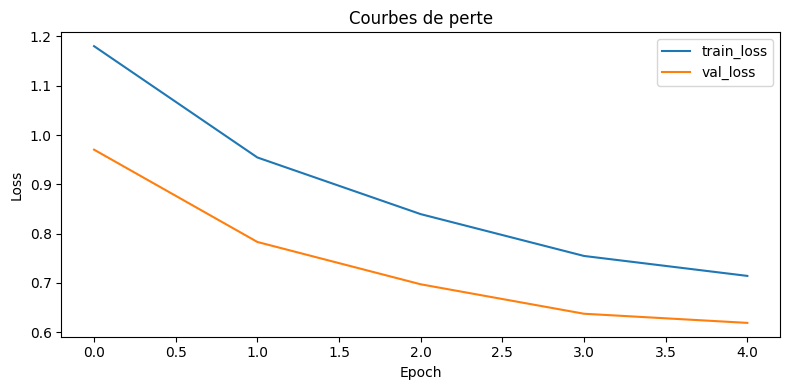

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Courbes de perte')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 3) Évaluation standard (sans MC Dropout)

In [6]:
probs_std = predict_probabilities(model, x_test)
preds_std = np.argmax(probs_std, axis=1)
acc_std = accuracy_score(y_test, preds_std)
print(f'Accuracy standard: {acc_std:.4f}')

Accuracy standard: 0.6831


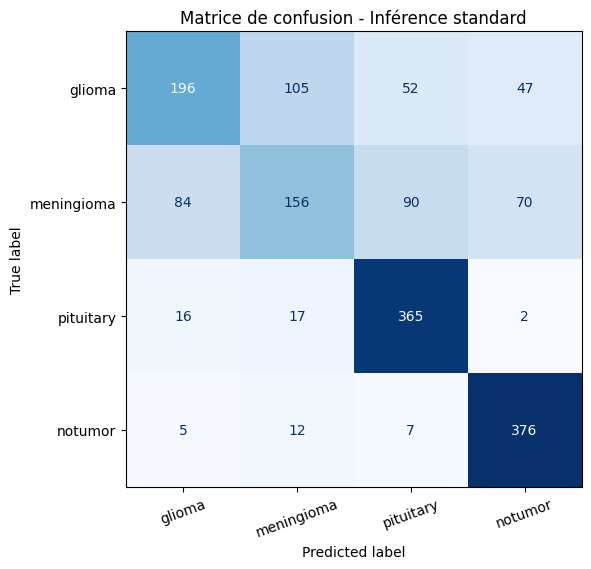

In [7]:
cm = confusion_matrix(y_test, preds_std)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_split.class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matrice de confusion - Inférence standard')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 4) Estimation d'incertitude avec MC Dropout

In [8]:
mc_summary = mc_dropout_predict(model=model, x_data=x_test, n_iter=N_ITER_MC)
acc_mc = accuracy_score(y_test, mc_summary.predicted_labels)
uncertainty_stats = summarize_uncertainty(mc_summary.max_probabilities, threshold=UNCERTAINTY_THRESHOLD)

entropy_mean = float(np.mean(mc_summary.predictive_entropy))
entropy_std = float(np.std(mc_summary.predictive_entropy))

print(f'Accuracy MC Dropout: {acc_mc:.4f}')
print(
    f"Seuil={uncertainty_stats['threshold']:.2f} | Incertaines={uncertainty_stats['uncertain_count']}/"
    f"{uncertainty_stats['total']} ({100*uncertainty_stats['uncertain_ratio']:.2f}%)"
)
print(f'Entropie prédictive: mean={entropy_mean:.4f}, std={entropy_std:.4f}')

Accuracy MC Dropout: 0.6787
Seuil=0.70 | Incertaines=894/1600 (55.88%)
Entropie prédictive: mean=0.8054, std=0.3403


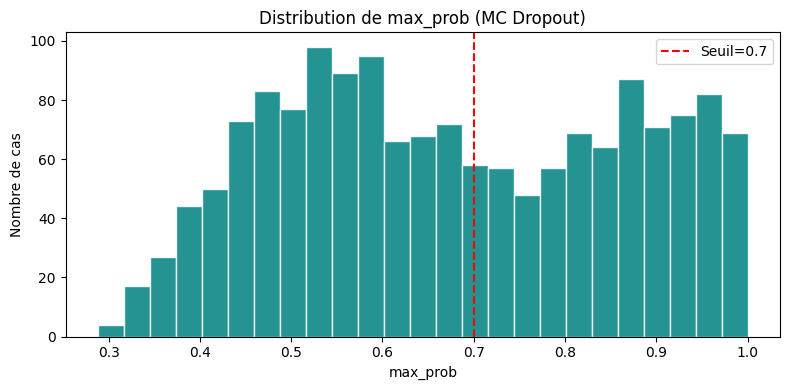

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(mc_summary.max_probabilities, bins=25, color='teal', alpha=0.85, edgecolor='white')
plt.axvline(UNCERTAINTY_THRESHOLD, color='red', linestyle='--', label=f'Seuil={UNCERTAINTY_THRESHOLD}')
plt.title('Distribution de max_prob (MC Dropout)')
plt.xlabel('max_prob')
plt.ylabel('Nombre de cas')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
uncertain_mask = mc_summary.max_probabilities < UNCERTAINTY_THRESHOLD
uncertain_indices = np.where(uncertain_mask)[0]

print(f'Cas incertains: {len(uncertain_indices)}')
n_show = min(10, len(uncertain_indices))
if n_show == 0:
    print('Aucun cas incertain avec ce seuil.')
else:
    print('Index | Vrai label | Pred label | max_prob | entropy')
    for idx in uncertain_indices[:n_show]:
        true_label = train_split.class_names[int(y_test[idx])]
        pred_label = train_split.class_names[int(mc_summary.predicted_labels[idx])]
        max_p = mc_summary.max_probabilities[idx]
        ent = mc_summary.predictive_entropy[idx]
        print(f'{idx:>5} | {true_label:<10} | {pred_label:<10} | {max_p:.3f} | {ent:.3f}')

Cas incertains: 894
Index | Vrai label | Pred label | max_prob | entropy
    1 | glioma     | glioma     | 0.347 | 1.353
    2 | glioma     | glioma     | 0.441 | 1.293
    3 | glioma     | pituitary  | 0.632 | 0.988
    4 | glioma     | notumor    | 0.374 | 1.243
    5 | glioma     | meningioma | 0.450 | 1.093
    6 | glioma     | meningioma | 0.606 | 1.000
    7 | glioma     | glioma     | 0.442 | 1.207
    8 | glioma     | glioma     | 0.342 | 1.348
    9 | glioma     | meningioma | 0.586 | 0.963
   10 | glioma     | pituitary  | 0.413 | 1.211
